# EDA inicial — Silent Churn Glamour

Objetivos:
1. Validar el data warehouse antes de construir cualquier modelo.
2. **Elegir la ventana `k` de campañas que define churn** (la suposición de v2 es `k=6`; aquí la cuestionamos con datos).
3. Caracterizar target y población.
4. Medir señal feature → churn.
5. Síntesis de viabilidad + reporte (`reports/eda_summary.md`).

Insumos: tablas crudas en BigQuery + `data/churn_v2.csv` (panel ya construido con `k=6`, filtro `compras_historicas>=4`).

In [12]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import cohen_kappa_score
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

findings: dict[str, object] = {}

In [13]:
from google.cloud import bigquery

PROJECT_ID = "glamour-peru-dw"
DATASET = "glamour_dw"

client = bigquery.Client(project=PROJECT_ID)

TABLES = [
    "dim_campana",
    "dim_coordinadora",
    "dim_fecha",
    "dim_producto",
    "dim_ubicacion",
    "dim_vendedor",
    "fact_pedidos",
    "fact_pedidos_detalle",
]

dfs = {
    table: client.query(f"SELECT * FROM `{PROJECT_ID}.{DATASET}.{table}`").to_dataframe()
    for table in TABLES
}

for name, df in dfs.items():
    print(f"{name:25s} {df.shape}")

dim_campana          = dfs["dim_campana"]
dim_coordinadora     = dfs["dim_coordinadora"]
dim_fecha            = dfs["dim_fecha"]
dim_producto         = dfs["dim_producto"]
dim_ubicacion        = dfs["dim_ubicacion"]
dim_vendedor         = dfs["dim_vendedor"]
fact_pedidos         = dfs["fact_pedidos"]
fact_pedidos_detalle = dfs["fact_pedidos_detalle"]

dim_campana               (156, 7)
dim_coordinadora          (7, 4)
dim_fecha                 (7670, 6)
dim_producto              (4989, 4)
dim_ubicacion             (1864, 5)
dim_vendedor              (21579, 10)
fact_pedidos              (57010, 10)
fact_pedidos_detalle      (339853, 9)


In [14]:
churn_v2 = pd.read_csv(DATA_DIR / "churn_v2.csv", parse_dates=["fecha_inicio_campana", "fecha_ingreso"])
print("churn_v2.csv:", churn_v2.shape)

valid_campanas = dim_campana[dim_campana["estado"].isna() | (dim_campana["estado"] != "CANCELADA")].copy()
campanas_rank = (
    valid_campanas.sort_values(["anio", "numero_campana"]).reset_index(drop=True)
)
campanas_rank["campana_rank"] = np.arange(1, len(campanas_rank) + 1)
campanas_rank = campanas_rank[["id_campana", "anio", "numero_campana", "fecha_inicio", "fecha_fin", "campana_rank"]]
print("campanas válidas:", len(campanas_rank), "| rango:", campanas_rank["fecha_inicio"].min(), "→", campanas_rank["fecha_inicio"].max())
campanas_rank.head()

churn_v2.csv: (21911, 66)
campanas válidas: 156 | rango: 2016-11-02 → 2026-04-11


,id_campana,anio,numero_campana,fecha_inicio,fecha_fin,campana_rank
0,16101,2016,1,2016-11-02,2016-12-04,1
1,16102,2016,2,2016-12-06,2017-01-13,2
2,17101,2017,3,2017-01-14,2017-02-16,3
3,17201,2017,4,2017-02-22,2017-02-22,4
4,17102,2017,5,2017-02-23,2017-04-20,5


## Bloque 1 — Validación del data warehouse

1.1 Cobertura temporal y volumen.
1.2 Calidad de `fact_pedidos`.
1.3 Vendedoras: edad, fecha_ingreso, tipos.
1.4 Coordinadora y ubicación: tasas de join + riesgo histórico vs actual.

Campañas totales: 156 | canceladas: 0 | válidas: 156
Años cubiertos: 2016 → 2026
Campañas por año:
anio
2016     2
2017    13
2018    20
2019    20
2020    12
2021    13
2022    13
2023    20
2024    15
2025    18
2026    10
dtype: int64


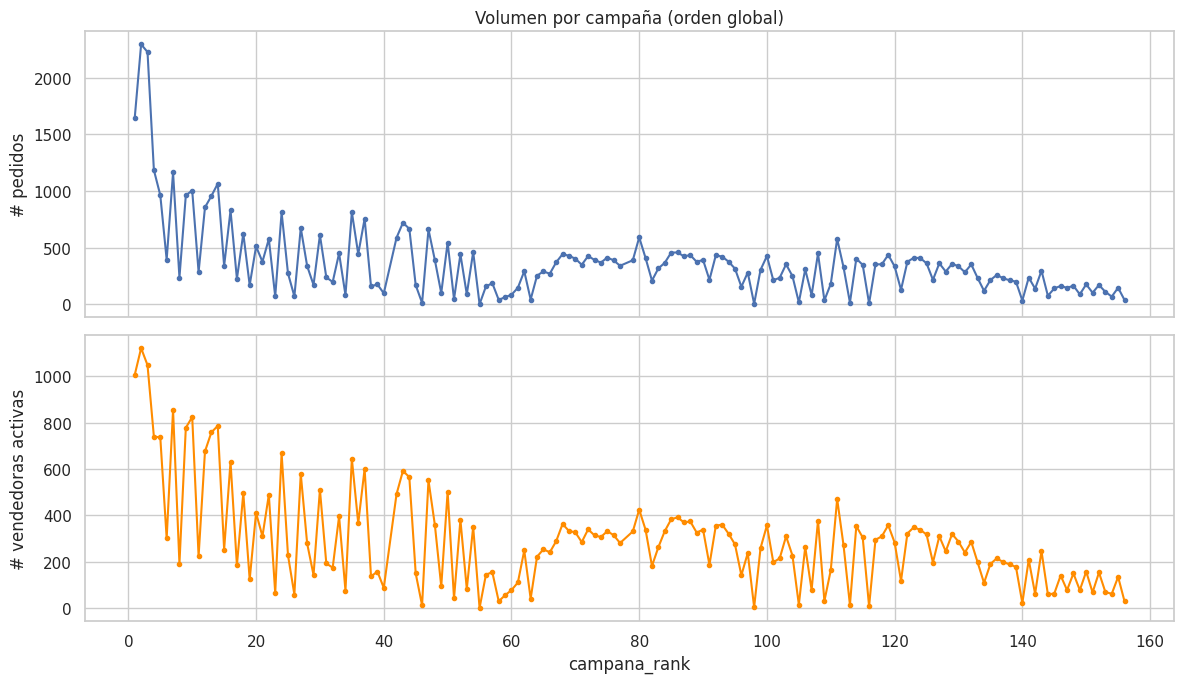

In [15]:
campanas_canceladas = (dim_campana["estado"] == "CANCELADA").sum()
print(f"Campañas totales: {len(dim_campana)} | canceladas: {campanas_canceladas} | válidas: {len(valid_campanas)}")
print(f"Años cubiertos: {valid_campanas['anio'].min()} → {valid_campanas['anio'].max()}")
print("Campañas por año:")
print(valid_campanas.groupby("anio").size())

pedidos_por_campana = (
    fact_pedidos.groupby("id_campana")
    .agg(n_pedidos=("id_pedido", "nunique"), n_vendedoras=("id_vendedor", "nunique"), monto=("monto_total_pedido", "sum"))
    .merge(campanas_rank[["id_campana", "campana_rank", "anio", "numero_campana", "fecha_inicio"]], on="id_campana", how="left")
    .sort_values("campana_rank")
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(pedidos_por_campana["campana_rank"], pedidos_por_campana["n_pedidos"], marker="o", ms=3)
axes[0].set_ylabel("# pedidos")
axes[0].set_title("Volumen por campaña (orden global)")
axes[1].plot(pedidos_por_campana["campana_rank"], pedidos_por_campana["n_vendedoras"], marker="o", ms=3, color="darkorange")
axes[1].set_ylabel("# vendedoras activas")
axes[1].set_xlabel("campana_rank")
plt.tight_layout()
plt.show()

findings["campanas_validas"] = int(len(valid_campanas))
findings["campanas_canceladas"] = int(campanas_canceladas)
findings["rango_anios"] = f"{int(valid_campanas['anio'].min())}–{int(valid_campanas['anio'].max())}"
findings["fechas_min_max"] = f"{valid_campanas['fecha_inicio'].min()} → {valid_campanas['fecha_inicio'].max()}"

In [16]:
print("--- Nulos en fact_pedidos ---")
print((fact_pedidos.isna().sum() / len(fact_pedidos)).round(4))

dup_pedidos = fact_pedidos["id_pedido"].duplicated().sum()
print(f"\nid_pedido duplicados: {dup_pedidos}")

print("\n--- Sanity de montos ---")
print(fact_pedidos[["monto_total_pedido", "monto_pagado"]].describe(percentiles=[0.01, 0.5, 0.99]))

neg_total = (fact_pedidos["monto_total_pedido"] < 0).sum()
neg_pagado = (fact_pedidos["monto_pagado"] < 0).sum()
pagado_gt_total = (fact_pedidos["monto_pagado"] > fact_pedidos["monto_total_pedido"] + 0.01).sum()
ratio_pago = fact_pedidos["monto_pagado"] / fact_pedidos["monto_total_pedido"].replace(0, np.nan)
print(f"monto_total_pedido < 0:                  {neg_total} ({neg_total/len(fact_pedidos):.2%})")
print(f"monto_pagado     < 0:                    {neg_pagado} ({neg_pagado/len(fact_pedidos):.2%})")
print(f"monto_pagado > monto_total_pedido:       {pagado_gt_total} ({pagado_gt_total/len(fact_pedidos):.2%})")
print(f"ratio_pago promedio: {ratio_pago.mean():.3f} | mediana: {ratio_pago.median():.3f}")

findings["dup_pedidos"] = int(dup_pedidos)
findings["pct_negativos_total"] = float(neg_total / len(fact_pedidos))
findings["pct_pagado_mayor_total"] = float(pagado_gt_total / len(fact_pedidos))

--- Nulos en fact_pedidos ---
id_pedido            0.0000
id_campana           0.0000
id_vendedor          0.0000
id_fecha             0.0000
id_coordinadora      0.0012
id_ubicacion         0.0013
monto_total_pedido   0.0000
monto_pagado         0.0000
es_nueva_vendedora   0.0000
tipo                 0.0000
dtype: float64

id_pedido duplicados: 0

--- Sanity de montos ---
       monto_total_pedido  monto_pagado
count          57010.0000    57010.0000
mean             358.2243      266.7370
std              295.3624      207.4886
min                0.0000        0.0000
1%                 0.0000        0.0000
50%              308.9600      232.6700
99%             1460.3460     1006.4538
max             8284.8400     5771.0000
monto_total_pedido < 0:                  0 (0.00%)
monto_pagado     < 0:                    0 (0.00%)
monto_pagado > monto_total_pedido:       1660 (2.91%)
ratio_pago promedio: 0.773 | mediana: 0.750


In [17]:
print("--- Nulos en dim_vendedor ---")
print((dim_vendedor.isna().sum() / len(dim_vendedor)).round(4))

print("\n--- Edad ---")
print(dim_vendedor["edad"].describe(percentiles=[0.01, 0.5, 0.99]))
edad_implausible = ((dim_vendedor["edad"] < 14) | (dim_vendedor["edad"] > 90)).sum()
print(f"Edades implausibles (<14 o >90): {edad_implausible} ({edad_implausible/len(dim_vendedor):.2%})")

print("\n--- tipo_vendedor ---")
print(dim_vendedor["tipo_vendedor"].value_counts(dropna=False))

print("\n--- sexo (csexpersona) ---")
print(dim_vendedor["csexpersona"].value_counts(dropna=False))

primera_compra = (
    fact_pedidos.merge(campanas_rank[["id_campana", "fecha_inicio"]], on="id_campana", how="left")
    .groupby("id_vendedor")["fecha_inicio"]
    .min()
    .rename("primera_compra_fecha")
)
vend_check = dim_vendedor[["id_vendedor", "fecha_ingreso"]].merge(primera_compra, on="id_vendedor", how="inner")
vend_check["fecha_ingreso"] = pd.to_datetime(vend_check["fecha_ingreso"])
vend_check["primera_compra_fecha"] = pd.to_datetime(vend_check["primera_compra_fecha"])
ingreso_post_compra = (vend_check["fecha_ingreso"] > vend_check["primera_compra_fecha"]).sum()
print(f"\nvendedoras con fecha_ingreso POSTERIOR a su primera compra: {ingreso_post_compra} ({ingreso_post_compra/len(vend_check):.2%})")
print("  → riesgo: si edad/fecha_ingreso son del estado actual, no representan el momento histórico.")

findings["edad_implausible_pct"] = float(edad_implausible / len(dim_vendedor))
findings["ingreso_posterior_a_compra_pct"] = float(ingreso_post_compra / len(vend_check))

--- Nulos en dim_vendedor ---
id_vendedor       0.0000
nombre_vendedor   0.0000
csexpersona       0.0000
ccodubigeo        0.0000
nmovil            0.0000
ccodrelacion      0.0000
id_coordinadora   0.0000
fecha_ingreso     0.0000
edad              0.5826
tipo_vendedor     0.0000
dtype: float64

--- Edad ---
count   9007.0000
mean      41.6846
std       14.6021
min     -199.0000
1%         4.0000
50%       42.0000
99%       72.0000
max      165.0000
Name: edad, dtype: float64
Edades implausibles (<14 o >90): 467 (2.16%)

--- tipo_vendedor ---
tipo_vendedor
Asesora    20516
Líder       1063
Name: count, dtype: int64

--- sexo (csexpersona) ---
csexpersona
F    21111
M      291
1      176
2        1
Name: count, dtype: int64

vendedoras con fecha_ingreso POSTERIOR a su primera compra: 8475 (71.56%)
  → riesgo: si edad/fecha_ingreso son del estado actual, no representan el momento histórico.


In [18]:
print("--- dim_coordinadora ---")
print(dim_coordinadora)
print("\nEstados:")
print(dim_coordinadora["estado"].value_counts(dropna=False))

coord_in_pedidos = fact_pedidos["id_coordinadora"].nunique()
coord_in_dim = dim_coordinadora["id_coordinadora"].nunique()
join_rate_coord = fact_pedidos["id_coordinadora"].isin(dim_coordinadora["id_coordinadora"]).mean()
print(f"\nid_coordinadora únicos en fact_pedidos: {coord_in_pedidos}")
print(f"id_coordinadora únicos en dim_coordinadora: {coord_in_dim}")
print(f"Tasa de join fact_pedidos→dim_coordinadora: {join_rate_coord:.2%}")

join_rate_ubigeo = dim_vendedor["ccodubigeo"].isin(dim_ubicacion["ccodubigeo"]).mean()
print(f"\nTasa de join dim_vendedor.ccodubigeo → dim_ubicacion: {join_rate_ubigeo:.2%}")

asignacion_actual = dim_vendedor.set_index("id_vendedor")["id_coordinadora"]
fp_join = fact_pedidos.dropna(subset=["id_coordinadora"]).copy()
fp_join["id_coord_actual"] = fp_join["id_vendedor"].map(asignacion_actual)
discrepancia = (fp_join["id_coordinadora"] != fp_join["id_coord_actual"]).mean()
print(f"\nPedidos con id_coordinadora ≠ asignación actual de dim_vendedor: {discrepancia:.2%}")
print("  → si discrepancia ≈ 0, dim_vendedor refleja estado ACTUAL (riesgo de leakage temporal)")
print("  → si es alta, las asignaciones cambiaron en el tiempo (más realista para entrenar)")

findings["n_coordinadoras"] = int(coord_in_dim)
findings["join_rate_coordinadora"] = float(join_rate_coord)
findings["join_rate_ubigeo"] = float(join_rate_ubigeo)
findings["discrepancia_coord_vendedor_pedido"] = float(discrepancia)

--- dim_coordinadora ---
  id_coordinadora nombre_coordinadora estado    edad
0        19721986              LETTIA      0 47.0000
1        19729612           PATRICIA       0  8.0000
2        19721983             MARISOL      1 47.0000
3        19721985            DIRECTA2      1     NaN
4        19721984                YULI      1     NaN
5        19738624               NELLY      1     NaN
6        19735959               ELENA      1     NaN

Estados:
estado
1    5
0    2
Name: count, dtype: int64

id_coordinadora únicos en fact_pedidos: 8
id_coordinadora únicos en dim_coordinadora: 7
Tasa de join fact_pedidos→dim_coordinadora: 99.74%

Tasa de join dim_vendedor.ccodubigeo → dim_ubicacion: 99.94%

Pedidos con id_coordinadora ≠ asignación actual de dim_vendedor: 0.00%
  → si discrepancia ≈ 0, dim_vendedor refleja estado ACTUAL (riesgo de leakage temporal)
  → si es alta, las asignaciones cambiaron en el tiempo (más realista para entrenar)


## Bloque 2 — Elección de la ventana `k` de churn

**Pregunta**: ¿`k=6` (v2) es la mejor ventana, o conviene otro valor?

Análisis:
1. Distribución de gaps entre compras consecutivas (CDF y modas).
2. Curva de churn por horizonte k=1..12 sobre sub-muestra fully observable.
3. Sensibilidad: para k ∈ {3..8}, dataset reconstruido + concordancia con k=6.

In [19]:
events = (
    fact_pedidos[["id_vendedor", "id_campana"]]
    .drop_duplicates()
    .merge(campanas_rank[["id_campana", "campana_rank"]], on="id_campana", how="inner")
    .sort_values(["id_vendedor", "campana_rank"])
    .reset_index(drop=True)
)

events["cum_purchases"] = events.groupby("id_vendedor").cumcount() + 1
events["next_rank"] = events.groupby("id_vendedor")["campana_rank"].shift(-1)
events["gap_to_next"] = events["next_rank"] - events["campana_rank"]

last_observed_rank = int(events["campana_rank"].max())
events["observable_horizon"] = last_observed_rank - events["campana_rank"]

print(f"Eventos de compra (vendedora, campaña): {len(events):,}")
print(f"Vendedoras únicas: {events['id_vendedor'].nunique():,}")
print(f"Última campaña observada (rank): {last_observed_rank}")
events.head()

Eventos de compra (vendedora, campaña): 45,050
Vendedoras únicas: 11,861
Última campaña observada (rank): 156


,id_vendedor,id_campana,campana_rank,cum_purchases,next_rank,gap_to_next,observable_horizon
0,11061213,23111,104,1,136.0000,32.0000,52
1,11061213,25108,136,2,NaN,NaN,20
2,19721994,16102,2,1,3.0000,1.0000,154
3,19721994,17101,3,2,5.0000,2.0000,153
4,19721994,17102,5,3,7.0000,2.0000,151


Gaps cerrados (con compras_historicas>=4): 19,159

Percentiles del gap (campañas):
count   19159.0000
mean        4.7079
std         8.8734
min         1.0000
25%         1.0000
50%         2.0000
75%         4.0000
90%        10.0000
95%        18.0000
99%        45.0000
max       142.0000
Name: gap_to_next, dtype: float64

Distribución (k=1..15):
             freq     pct     cdf
gap_to_next                      
1            7748 40.4400 40.4400
2            3865 20.1700 60.6100
3            1898  9.9100 70.5200
4            1064  5.5500 76.0700
5             845  4.4100 80.4800
6             543  2.8300 83.3200
7             451  2.3500 85.6700
8             306  1.6000 87.2700
9             276  1.4400 88.7100
10            256  1.3400 90.0500
11            198  1.0300 91.0800
12            160  0.8400 91.9200
13            132  0.6900 92.6000
14            125  0.6500 93.2600
15            110  0.5700 93.8300


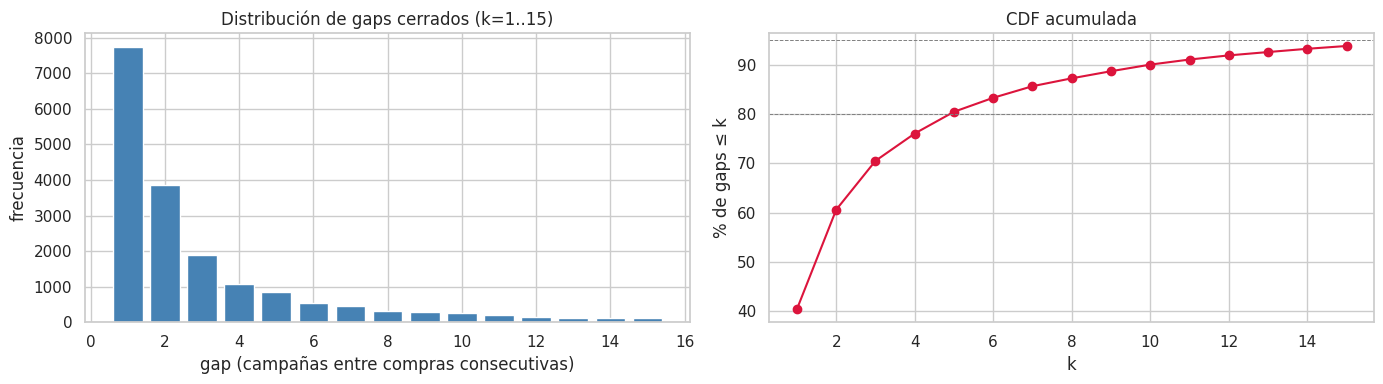

In [20]:
events_h4 = events[events["cum_purchases"] >= 4]
gaps = events_h4["gap_to_next"].dropna().astype(int)

print(f"Gaps cerrados (con compras_historicas>=4): {len(gaps):,}")
print("\nPercentiles del gap (campañas):")
print(gaps.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

gap_freq = gaps.value_counts().sort_index()
gap_pct = (gap_freq / len(gaps) * 100).round(2)
gap_cdf = (gap_freq.cumsum() / len(gaps) * 100).round(2)
tabla_gaps = pd.DataFrame({"freq": gap_freq, "pct": gap_pct, "cdf": gap_cdf}).head(15)
print("\nDistribución (k=1..15):")
print(tabla_gaps)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(gap_freq.head(15).index, gap_freq.head(15).values, color="steelblue")
ax[0].set_xlabel("gap (campañas entre compras consecutivas)")
ax[0].set_ylabel("frecuencia")
ax[0].set_title("Distribución de gaps cerrados (k=1..15)")

ax[1].plot(gap_cdf.head(15).index, gap_cdf.head(15).values, marker="o", color="crimson")
ax[1].axhline(80, ls="--", color="gray", lw=0.7)
ax[1].axhline(95, ls="--", color="gray", lw=0.7)
ax[1].set_xlabel("k")
ax[1].set_ylabel("% de gaps ≤ k")
ax[1].set_title("CDF acumulada")
plt.tight_layout()
plt.show()

findings["gap_p50"] = float(gaps.quantile(0.5))
findings["gap_p75"] = float(gaps.quantile(0.75))
findings["gap_p90"] = float(gaps.quantile(0.9))
findings["pct_gaps_ge_4"] = float((gaps >= 4).mean())
findings["pct_gaps_ge_6"] = float((gaps >= 6).mean())

Sub-muestra fully-observable (>= 12 campañas futuras): 21,404 (95.8% de events_h4)
     k  pct_silent  hazard
0    1      0.6474 -0.3526
1    2      0.4736  0.2686
2    3      0.3877  0.1812
3    4      0.3403  0.1223
4    5      0.3022  0.1120
5    6      0.2778  0.0809
6    7      0.2571  0.0743
7    8      0.2429  0.0552
8    9      0.2301  0.0529
9   10      0.2181  0.0518
10  11      0.2089  0.0424
11  12      0.2014  0.0358


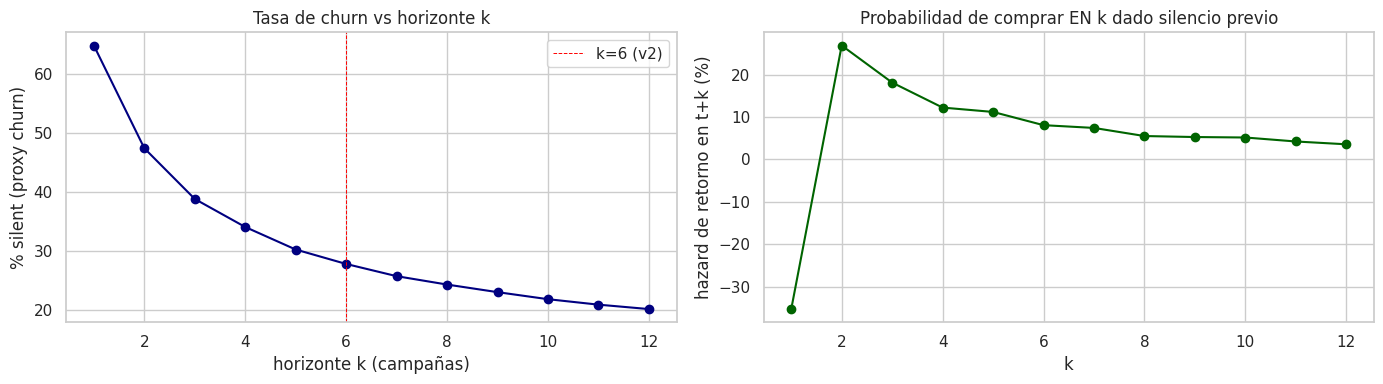

In [21]:
MAX_K = 12
subset = events_h4[events_h4["observable_horizon"] >= MAX_K].copy()
print(f"Sub-muestra fully-observable (>= {MAX_K} campañas futuras): {len(subset):,} ({len(subset)/len(events_h4):.1%} de events_h4)")

rows = []
for k in range(1, MAX_K + 1):
    silent = (subset["gap_to_next"].isna() | (subset["gap_to_next"] > k)).mean()
    rows.append({"k": k, "pct_silent": silent})
horizon_curve = pd.DataFrame(rows)

horizon_curve["hazard"] = (
    -horizon_curve["pct_silent"].diff().fillna(1 - horizon_curve["pct_silent"].iloc[0])
    / horizon_curve["pct_silent"].shift(1).fillna(1.0)
)
print(horizon_curve)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(horizon_curve["k"], horizon_curve["pct_silent"] * 100, marker="o", color="navy")
ax[0].set_xlabel("horizonte k (campañas)")
ax[0].set_ylabel("% silent (proxy churn)")
ax[0].set_title("Tasa de churn vs horizonte k")
ax[0].axvline(6, ls="--", color="red", lw=0.7, label="k=6 (v2)")
ax[0].legend()

ax[1].plot(horizon_curve["k"], horizon_curve["hazard"] * 100, marker="o", color="darkgreen")
ax[1].set_xlabel("k")
ax[1].set_ylabel("hazard de retorno en t+k (%)")
ax[1].set_title("Probabilidad de comprar EN k dado silencio previo")
plt.tight_layout()
plt.show()

findings["horizon_curve"] = horizon_curve.to_dict(orient="records")

Sensibilidad por k:
   k  n_obs  n_vendedoras  churn_rate  positives
0  3  22158          3176      0.3915       8674
1  4  22103          3173      0.3433       7587
2  5  21981          3165      0.3040       6683
3  6  21925          3159      0.2791       6119
4  7  21803          3153      0.2576       5616
5  8  21752          3151      0.2432       5290

Concordancia con churn (k=6):
   k  kappa_vs_6  agree_pct
0  3      0.7526     0.8882
1  4      0.8530     0.9367
2  5      0.9401     0.9752
3  6      1.0000     1.0000
4  7      0.9473     0.9793
5  8      0.9098     0.9652


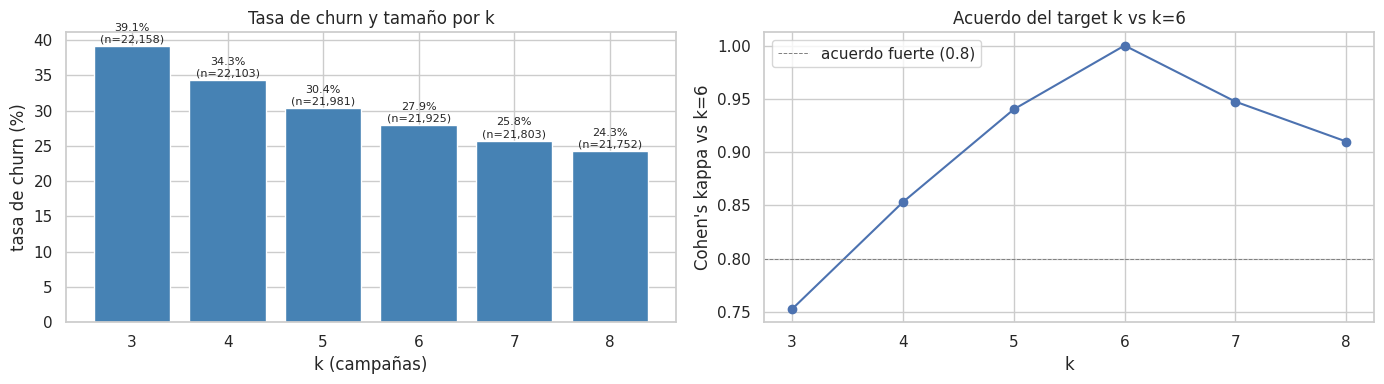

In [22]:
K_VALUES = [3, 4, 5, 6, 7, 8]
rows_per_k = {}
rows = []
for k in K_VALUES:
    elig = events_h4[events_h4["observable_horizon"] >= k].copy()
    elig["churn_k"] = (elig["gap_to_next"].isna() | (elig["gap_to_next"] > k)).astype(int)
    rows_per_k[k] = elig
    rows.append({
        "k": k,
        "n_obs": len(elig),
        "n_vendedoras": elig["id_vendedor"].nunique(),
        "churn_rate": elig["churn_k"].mean(),
        "positives": int(elig["churn_k"].sum()),
    })
sensitivity = pd.DataFrame(rows)
print("Sensibilidad por k:")
print(sensitivity)

ref = rows_per_k[6][["id_vendedor", "campana_rank", "churn_k"]].rename(columns={"churn_k": "churn_6"})
rows_kappa = []
for k in K_VALUES:
    if k == 6:
        rows_kappa.append({"k": k, "kappa_vs_6": 1.0, "agree_pct": 1.0})
        continue
    cmp = (
        rows_per_k[k][["id_vendedor", "campana_rank", "churn_k"]]
        .rename(columns={"churn_k": f"churn_{k}"})
        .merge(ref, on=["id_vendedor", "campana_rank"], how="inner")
    )
    if len(cmp) == 0:
        rows_kappa.append({"k": k, "kappa_vs_6": np.nan, "agree_pct": np.nan})
        continue
    rows_kappa.append({
        "k": k,
        "kappa_vs_6": cohen_kappa_score(cmp[f"churn_{k}"], cmp["churn_6"]),
        "agree_pct": (cmp[f"churn_{k}"] == cmp["churn_6"]).mean(),
    })
kappa = pd.DataFrame(rows_kappa)
print("\nConcordancia con churn (k=6):")
print(kappa)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(sensitivity["k"].astype(str), sensitivity["churn_rate"] * 100, color="steelblue")
for i, (k, r, n) in enumerate(zip(sensitivity["k"], sensitivity["churn_rate"], sensitivity["n_obs"])):
    ax[0].text(i, r * 100 + 0.5, f"{r:.1%}\n(n={n:,})", ha="center", fontsize=8)
ax[0].set_xlabel("k (campañas)")
ax[0].set_ylabel("tasa de churn (%)")
ax[0].set_title("Tasa de churn y tamaño por k")

ax[1].plot(kappa["k"], kappa["kappa_vs_6"], marker="o")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Cohen's kappa vs k=6")
ax[1].set_title("Acuerdo del target k vs k=6")
ax[1].axhline(0.8, ls="--", color="gray", lw=0.7, label="acuerdo fuerte (0.8)")
ax[1].legend()
plt.tight_layout()
plt.show()

findings["sensitivity_k"] = sensitivity.to_dict(orient="records")
findings["kappa_vs_k6"] = kappa.to_dict(orient="records")

In [23]:
rates = sensitivity.set_index("k")["churn_rate"]
deltas = rates.diff(-1).abs()
print("Delta absoluta entre tasas consecutivas:")
print(deltas)

k_codo_candidates = deltas[deltas < 0.02].index.tolist()
k_recomendado = k_codo_candidates[0] if k_codo_candidates else int(rates.idxmin())
print(f"\nk recomendado por codo (Δtasa < 2pp): {k_recomendado}")
print("(criterio aproximado; ajustar según ventana de intervención del negocio)")
findings["k_recomendado"] = int(k_recomendado)

Delta absoluta entre tasas consecutivas:
k
3   0.0482
4   0.0392
5   0.0249
6   0.0215
7   0.0144
8      NaN
Name: churn_rate, dtype: float64

k recomendado por codo (Δtasa < 2pp): 7
(criterio aproximado; ajustar según ventana de intervención del negocio)


## Bloque 3 — Target y población

Sobre `churn_v2.csv`:
- Tasa de churn global y por año.
- Sensibilidad de `compras_historicas`.
- Sesgo de borde temporal.

Tasa de churn global (k=6, compras_historicas>=4): 27.89%
n filas: 21,911 | vendedoras únicas: 3,155

Por año:
                 n  churn_rate
anio_campana                  
2017          2473      0.2349
2018          3147      0.3073
2019          2785      0.3235
2020           978      0.3016
2021          2225      0.2189
2022          2367      0.2404
2023          2595      0.3060
2024          2623      0.2432
2025          2364      0.3211
2026           354      0.3390


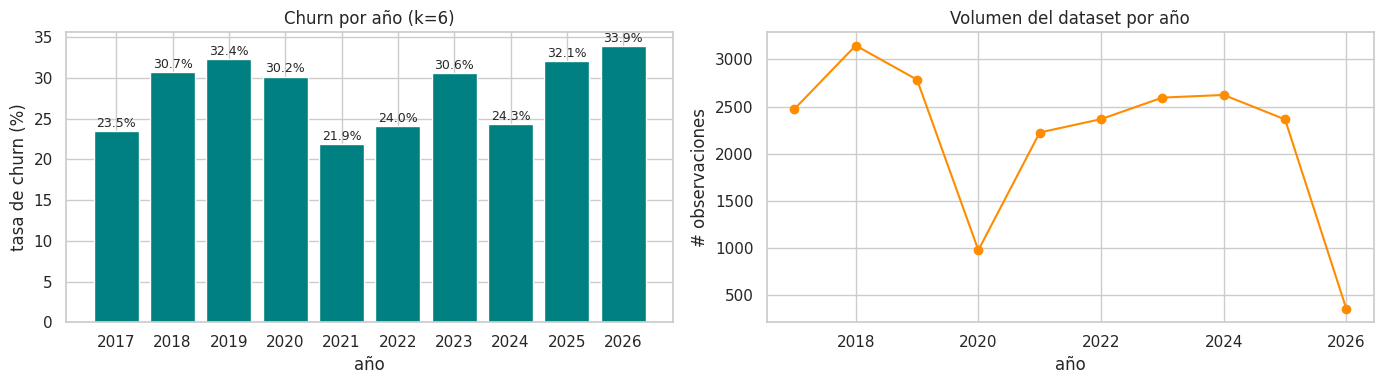

In [24]:
churn_rate_global = churn_v2["churn"].mean()
print(f"Tasa de churn global (k=6, compras_historicas>=4): {churn_rate_global:.2%}")
print(f"n filas: {len(churn_v2):,} | vendedoras únicas: {churn_v2['id_vendedor'].nunique():,}")

tasa_anual = churn_v2.groupby("anio_campana").agg(n=("churn", "size"), churn_rate=("churn", "mean"))
print("\nPor año:")
print(tasa_anual)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(tasa_anual.index.astype(str), tasa_anual["churn_rate"] * 100, color="teal")
ax[0].set_xlabel("año")
ax[0].set_ylabel("tasa de churn (%)")
ax[0].set_title("Churn por año (k=6)")
for i, v in enumerate(tasa_anual["churn_rate"] * 100):
    ax[0].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

ax[1].plot(tasa_anual.index, tasa_anual["n"], marker="o", color="darkorange")
ax[1].set_xlabel("año")
ax[1].set_ylabel("# observaciones")
ax[1].set_title("Volumen del dataset por año")
plt.tight_layout()
plt.show()

findings["churn_rate_v2"] = float(churn_rate_global)
findings["churn_rate_por_anio"] = tasa_anual.reset_index().to_dict(orient="records")

   min_compras_historicas  n_obs  churn_rate
0                       1  44531      0.3951
1                       2  32716      0.3350
2                       3  26260      0.3030
3                       4  21925      0.2791
4                       5  18766      0.2627
5                       6  16291      0.2480
6                       8  12723      0.2197
7                      10  10279      0.2011


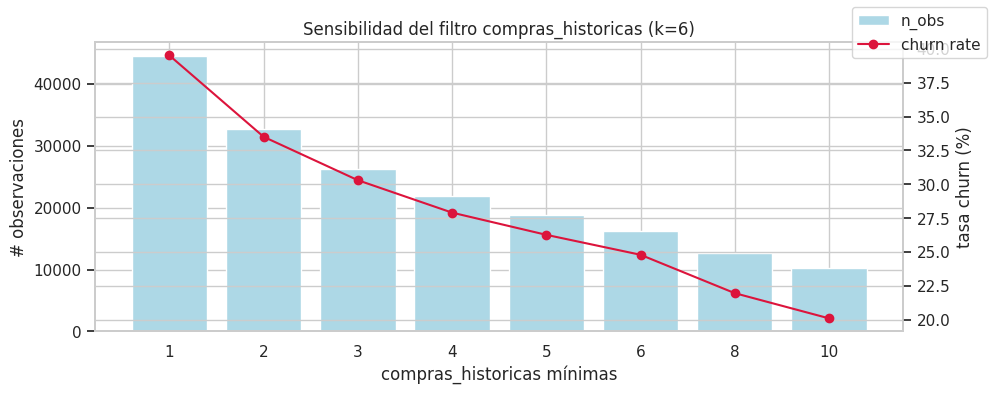

In [25]:
rows_h = []
for h in [1, 2, 3, 4, 5, 6, 8, 10]:
    sub = events[events["cum_purchases"] >= h].copy()
    sub = sub[sub["observable_horizon"] >= 6]
    sub["churn_6"] = (sub["gap_to_next"].isna() | (sub["gap_to_next"] > 6)).astype(int)
    rows_h.append({
        "min_compras_historicas": h,
        "n_obs": len(sub),
        "churn_rate": sub["churn_6"].mean() if len(sub) else np.nan,
    })
tab_h = pd.DataFrame(rows_h)
print(tab_h)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.bar(tab_h["min_compras_historicas"].astype(str), tab_h["n_obs"], color="lightblue", label="n_obs")
ax2.plot(tab_h["min_compras_historicas"].astype(str), tab_h["churn_rate"] * 100, color="crimson", marker="o", label="churn rate")
ax1.set_xlabel("compras_historicas mínimas")
ax1.set_ylabel("# observaciones")
ax2.set_ylabel("tasa churn (%)")
ax1.set_title("Sensibilidad del filtro compras_historicas (k=6)")
fig.legend(loc="upper right")
plt.tight_layout()
plt.show()

findings["sensibilidad_historia"] = tab_h.to_dict(orient="records")

In [26]:
ultimas_campanas = campanas_rank.tail(6)
print("Últimas 6 campañas (sin target observable para churn k=6):")
print(ultimas_campanas[["id_campana", "anio", "numero_campana", "fecha_inicio"]])

perdidas = events_h4[events_h4["observable_horizon"] < 6]
print(f"\nObservaciones (vendedora,t) con compras_historicas>=4 que QUEDAN sin target por borde: {len(perdidas):,}")
print(f"% del total con historia>=4: {len(perdidas)/len(events_h4):.2%}")

findings["obs_perdidas_borde"] = int(len(perdidas))
findings["pct_obs_perdidas_borde"] = float(len(perdidas) / len(events_h4))

Últimas 6 campañas (sin target observable para churn k=6):
     id_campana  anio  numero_campana fecha_inicio
150       26105  2026             151   2026-02-13
151       26106  2026             152   2026-03-04
152       26108  2026             153   2026-03-13
153       26107  2026             154   2026-03-23
154       26109  2026             155   2026-04-06
155       26110  2026             156   2026-04-11

Observaciones (vendedora,t) con compras_historicas>=4 que QUEDAN sin target por borde: 417
% del total con historia>=4: 1.87%


## Bloque 4 — Features vs target

Sobre `churn_v2.csv`. Buscamos señal de separabilidad univariada y por categoría.

In [27]:
EXCLUDE = {
    "id_vendedor", "id_campana_obs", "campana_rank_obs", "fecha_inicio_campana", "fecha_ingreso",
    "id_coordinadora", "ccodubigeo", "compro_en_obs",
    "churn",
    "compro_t1", "compro_t2", "compro_t3", "compro_t4", "compro_t5", "compro_t6",
    "monto_t1", "monto_t2", "monto_t3", "monto_t4", "monto_t5", "monto_t6",
}
feature_cols = [c for c in churn_v2.columns if c not in EXCLUDE]
num_cols = churn_v2[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in feature_cols if c not in num_cols]
print(f"Numéricas: {len(num_cols)} | categóricas: {len(cat_cols)}")
print("Categóricas:", cat_cols)

y = churn_v2["churn"].astype(int)
spearman_rows = []
for col in num_cols:
    x = churn_v2[col]
    mask = x.notna()
    if mask.sum() < 100 or x[mask].nunique() < 2:
        continue
    rho, _ = spearmanr(x[mask], y[mask])
    spearman_rows.append({"feature": col, "spearman": rho, "n_valid": int(mask.sum())})
spearman_df = pd.DataFrame(spearman_rows).assign(abs_rho=lambda d: d["spearman"].abs()).sort_values("abs_rho", ascending=False)
print("\nTop 15 |spearman| con churn:")
print(spearman_df.head(15))
findings["spearman_top"] = spearman_df.head(15)[["feature", "spearman"]].to_dict(orient="records")

Numéricas: 40 | categóricas: 5
Categóricas: ['sexo_vendedor', 'tipo_vendedor', 'distrito', 'provincia', 'departamento']

Top 15 |spearman| con churn:
              feature  spearman  n_valid  abs_rho
26   monto_pagado_u12   -0.3534    21911   0.3534
25    monto_total_u12   -0.3521    21911   0.3521
20    monto_pagado_u6   -0.3417    21911   0.3417
19     monto_total_u6   -0.3402    21911   0.3402
31   avg_productos_u6   -0.3386    21911   0.3386
32        unidades_u6   -0.3379    21911   0.3379
24    num_compras_u12   -0.3365    21911   0.3365
18     num_compras_u6   -0.3228    21911   0.3228
27    tasa_compra_u12   -0.3207    21911   0.3207
21     tasa_compra_u6   -0.3194    21911   0.3194
30  avg_categorias_u6   -0.3076    21911   0.3076
14    monto_pagado_u3   -0.3020    21911   0.3020
13     monto_total_u3   -0.3002    21911   0.3002
15     tasa_compra_u3   -0.2724    21911   0.2724
12     num_compras_u3   -0.2724    21911   0.2724


Top 15 mutual information con churn:
               feature     mi
27    monto_pagado_u12 0.0661
28     tasa_compra_u12 0.0636
21     monto_pagado_u6 0.0628
19      num_compras_u6 0.0620
26     monto_total_u12 0.0609
33         unidades_u6 0.0596
32    avg_productos_u6 0.0577
20      monto_total_u6 0.0576
25     num_compras_u12 0.0574
22      tasa_compra_u6 0.0532
15     monto_pagado_u3 0.0508
14      monto_total_u3 0.0502
31   avg_categorias_u6 0.0499
13      num_compras_u3 0.0391
17  ticket_promedio_u3 0.0374


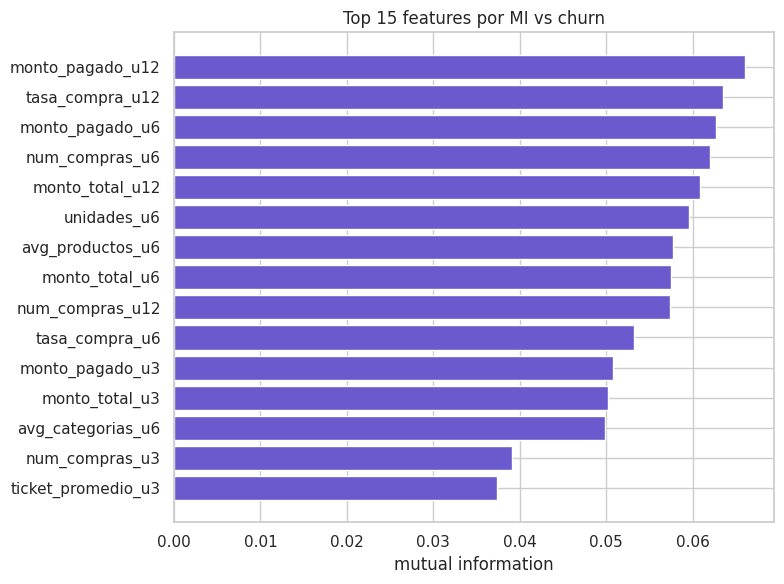

In [28]:
X_num = churn_v2[num_cols].apply(lambda s: s.fillna(s.median())).to_numpy()
mi = mutual_info_classif(X_num, y, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({"feature": num_cols, "mi": mi}).sort_values("mi", ascending=False)
print("Top 15 mutual information con churn:")
print(mi_df.head(15))

fig, ax = plt.subplots(figsize=(8, 6))
top = mi_df.head(15).iloc[::-1]
ax.barh(top["feature"], top["mi"], color="slateblue")
ax.set_xlabel("mutual information")
ax.set_title("Top 15 features por MI vs churn")
plt.tight_layout()
plt.show()
findings["mi_top"] = mi_df.head(15).to_dict(orient="records")

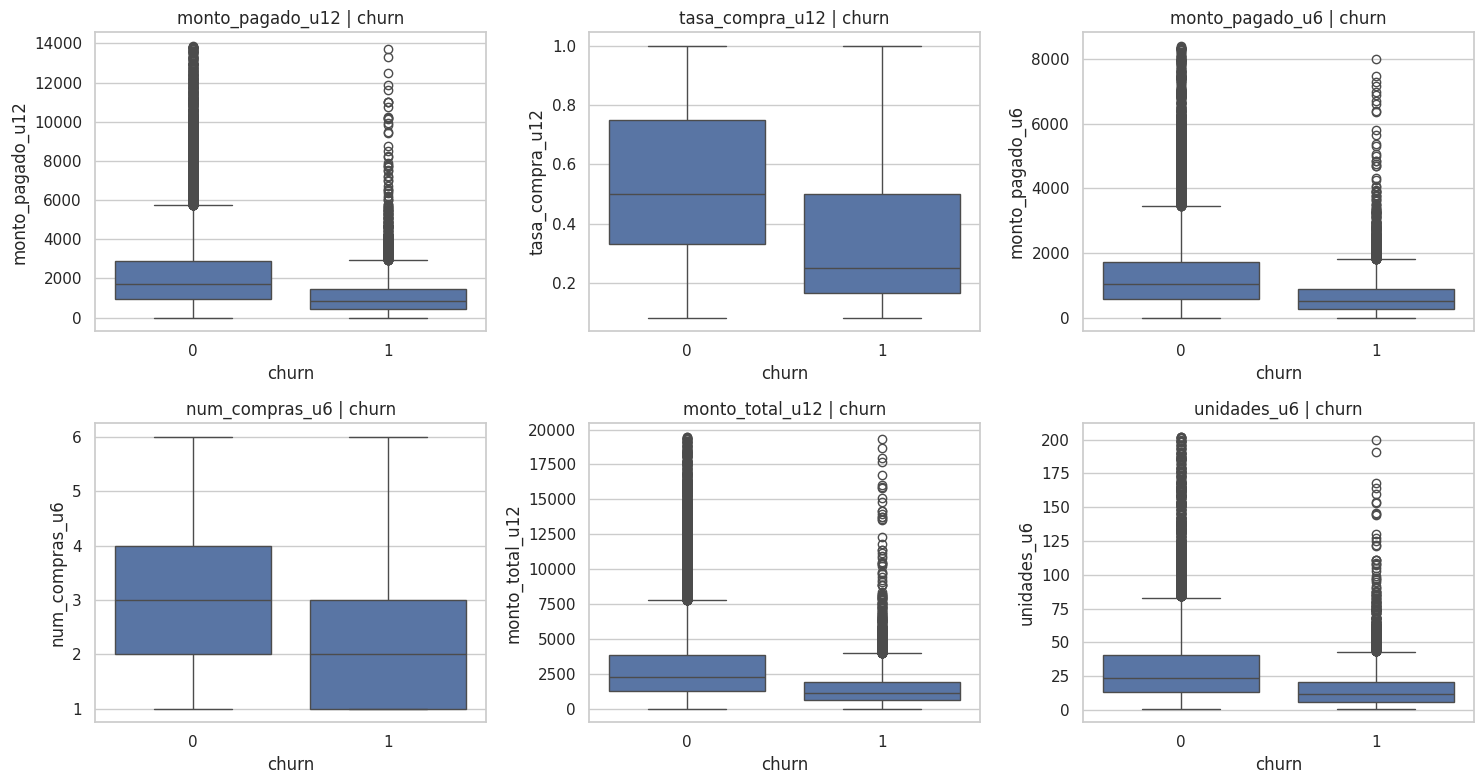

In [29]:
top_features = mi_df.head(6)["feature"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, top_features):
    data = churn_v2[[col, "churn"]].dropna()
    upper = data[col].quantile(0.99)
    sns.boxplot(data=data[data[col] <= upper], x="churn", y=col, ax=ax)
    ax.set_title(f"{col} | churn")
plt.tight_layout()
plt.show()

In [30]:
for col in ["tipo_vendedor", "sexo_vendedor", "estado_coordinadora", "departamento", "es_nueva_vendedora"]:
    if col not in churn_v2.columns:
        continue
    g = churn_v2.groupby(col, dropna=False).agg(n=("churn", "size"), churn_rate=("churn", "mean")).sort_values("n", ascending=False)
    g_top = g.head(15)
    print(f"\n--- {col} ---")
    print(g_top)
    findings[f"churn_por_{col}"] = g_top.reset_index().to_dict(orient="records")


--- tipo_vendedor ---
                   n  churn_rate
tipo_vendedor                   
Asesora        19114      0.2893
Líder           2797      0.2081

--- sexo_vendedor ---
                   n  churn_rate
sexo_vendedor                   
F              21151      0.2807
M                607      0.2125
1                153      0.2876

--- estado_coordinadora ---
                         n  churn_rate
estado_coordinadora                   
1.0000               21744      0.2774
0.0000                 152      0.4868
NaN                     15      0.3333

--- departamento ---
                 n  churn_rate
departamento                  
lima          3269      0.2261
piura         1707      0.2923
ancash        1703      0.2402
la libertad   1523      0.3283
junin         1393      0.3144
cajamarca     1097      0.3218
Lima           988      0.2540
lambayeque     986      0.2961
ica            922      0.3069
san martin     830      0.2976
amazonas       824      0.2961
arequipa

## Bloque 5 — Síntesis y reporte

La celda final escribe `reports/eda_summary.md` con los hallazgos numéricos.

In [31]:
from datetime import date

def fmt_pct(v, digits=2):
    return f"{v*100:.{digits}f}%" if v is not None and not pd.isna(v) else "—"

def fmt_num(v, digits=2):
    if v is None or (isinstance(v, float) and pd.isna(v)):
        return "—"
    if isinstance(v, (int, np.integer)):
        return f"{int(v):,}"
    return f"{v:.{digits}f}"

def df_to_md(records, cols, headers=None):
    headers = headers or cols
    lines = ["| " + " | ".join(headers) + " |", "|" + "|".join(["---"] * len(cols)) + "|"]
    for r in records:
        row = []
        for c in cols:
            v = r.get(c)
            if isinstance(v, float):
                row.append(f"{v:.4f}")
            elif isinstance(v, (int, np.integer)):
                row.append(f"{int(v):,}")
            else:
                row.append(str(v))
        lines.append("| " + " | ".join(row) + " |")
    return "\n".join(lines)

k_rec = findings.get("k_recomendado", 6)

md = f"""# EDA inicial — Silent Churn Glamour

*Generado por `notebooks/01_eda.ipynb` el {date.today().isoformat()}*

## TL;DR

- **Datos**: {findings['campanas_validas']} campañas válidas ({findings['rango_anios']}), {len(events):,} eventos de compra de {events['id_vendedor'].nunique():,} vendedoras.
- **Calidad**: {fmt_pct(findings['pct_negativos_total'])} montos negativos, {fmt_pct(findings['pct_pagado_mayor_total'])} con pagado>total, {fmt_pct(findings['edad_implausible_pct'])} edades implausibles.
- **Riesgo de leakage**: discrepancia coordinadora pedido vs vendedor = {fmt_pct(findings['discrepancia_coord_vendedor_pedido'])}.
- **Ventana k recomendada**: **k = {k_rec}** (criterio de codo Δtasa < 2pp). v2 actualmente usa k=6.
- **Tasa de churn (v2, k=6, hist≥4)**: {fmt_pct(findings['churn_rate_v2'])} sobre {len(churn_v2):,} filas.
- **Sesgo de borde**: {fmt_pct(findings['pct_obs_perdidas_borde'])} de obs con historia≥4 quedan sin target por las últimas 6 campañas.

---

## 1. Validación del data warehouse

| Métrica | Valor |
|---|---|
| Campañas válidas | {findings['campanas_validas']} |
| Campañas canceladas | {findings['campanas_canceladas']} |
| Rango de años | {findings['rango_anios']} |
| Rango de fechas | {findings['fechas_min_max']} |
| Pedidos duplicados (id_pedido) | {findings['dup_pedidos']} |
| Montos totales negativos | {fmt_pct(findings['pct_negativos_total'])} |
| Pagado > total | {fmt_pct(findings['pct_pagado_mayor_total'])} |
| Edades implausibles (<14 o >90) | {fmt_pct(findings['edad_implausible_pct'])} |
| `fecha_ingreso` posterior a 1ª compra | {fmt_pct(findings['ingreso_posterior_a_compra_pct'])} |
| Coordinadoras únicas | {findings['n_coordinadoras']} |
| Tasa de join coordinadora | {fmt_pct(findings['join_rate_coordinadora'])} |
| Tasa de join ubigeo | {fmt_pct(findings['join_rate_ubigeo'])} |
| **Discrepancia coord (pedido vs vendedor)** | {fmt_pct(findings['discrepancia_coord_vendedor_pedido'])} |

**Lecturas:**
- Si la discrepancia de coordinadora es ~0%, `dim_vendedor.id_coordinadora` refleja el estado **actual**, no histórico → riesgo de leakage temporal. Usar el `id_coordinadora` de fact_pedidos cuando se construyan features.
- Las edades implausibles son un porcentaje bajo, pero validar si la edad es estática (riesgo similar al de coordinadora).

---

## 2. Elección de la ventana de churn `k`

### 2.1 Distribución de gaps cerrados (compras_historicas≥4)

| Estadístico | Campañas |
|---|---|
| P50 | {fmt_num(findings['gap_p50'], 1)} |
| P75 | {fmt_num(findings['gap_p75'], 1)} |
| P90 | {fmt_num(findings['gap_p90'], 1)} |
| % gaps ≥ 4 | {fmt_pct(findings['pct_gaps_ge_4'])} |
| % gaps ≥ 6 | {fmt_pct(findings['pct_gaps_ge_6'])} |

### 2.2 Sensibilidad por k

{df_to_md(findings['sensitivity_k'], ['k', 'n_obs', 'n_vendedoras', 'churn_rate', 'positives'], ['k', 'n_obs', 'n_vendedoras', 'churn_rate', 'positivos'])}

### 2.3 Concordancia con k=6

{df_to_md(findings['kappa_vs_k6'], ['k', 'kappa_vs_6', 'agree_pct'], ['k', 'kappa', '% acuerdo'])}

**Recomendación**: **k = {k_rec}**. Tradeoff:
- k pequeño → más positivos y reactivo, pero más "falsos churn" (vendedoras esporádicas que vuelven).
- k grande → definición más estable pero menos margen de intervención.
- Si el negocio puede actuar en 2-3 campañas, conviene k modesto; si la intervención toma 4+, k grande.

---

## 3. Target y población

- **Tasa de churn global (v2)**: {fmt_pct(findings['churn_rate_v2'])} sobre {len(churn_v2):,} filas, {churn_v2['id_vendedor'].nunique():,} vendedoras únicas.

### Por año

{df_to_md(findings['churn_rate_por_anio'], ['anio_campana', 'n', 'churn_rate'], ['año', 'n', 'churn_rate'])}

### Sensibilidad del filtro `compras_historicas` (k=6)

{df_to_md(findings['sensibilidad_historia'], ['min_compras_historicas', 'n_obs', 'churn_rate'])}

### Sesgo de borde temporal

- {findings['obs_perdidas_borde']:,} observaciones ({fmt_pct(findings['pct_obs_perdidas_borde'])}) con historia≥4 quedan sin target porque caen en las últimas 6 campañas del DW. El dataset sub-representa el estado más reciente; reentrenar / re-extraer cuando lleguen nuevas campañas.

---

## 4. Señal de features

### Top 15 por mutual information

{df_to_md(findings['mi_top'], ['feature', 'mi'], ['feature', 'MI'])}

### Top 15 por |Spearman|

{df_to_md(findings['spearman_top'], ['feature', 'spearman'])}

**Lectura rápida**: si la MI máxima > ~0.05 y hay 3-5 features con MI > 0.02, hay señal suficiente para superar claramente al baseline.

---

## 5. Conclusión: ¿es viable un modelo de churn?

Marcar / completar tras leer las tablas:

- [ ] Tasa de churn no trivial (entre 10% y 50%) — actual: {fmt_pct(findings['churn_rate_v2'])}.
- [ ] Hay separabilidad univariada (≥3 features con MI > 0.02).
- [ ] La definición temporal es estable inter-anual.
- [ ] Volumen suficiente para los modelos previstos.
- [ ] Riesgos identificados:
  - Estado actual (coordinadora, edad, tipo_vendedor) que no refleja histórico → potencial leakage.
  - Drift temporal entre años.
  - Sesgo de borde (últimas 6 campañas sin target).

**Próximos pasos sugeridos**:
1. Si k_recomendado ≠ 6, generar `qry_churn_v3.sql` con la nueva ventana y re-extraer.
2. Construir baseline (LogReg / LightGBM) con CV temporal (split por `campana_rank_obs`).
3. Profundizar en features de tendencia (`tendencia_*`, `ticket_u3_vs_u12`).
4. Verificar el caso del `id_coordinadora` histórico si la discrepancia es ~0.
"""

out = REPORTS_DIR / "eda_summary.md"
out.write_text(md, encoding="utf-8")
print(f"Reporte escrito: {out} ({len(md):,} bytes)")

Reporte escrito: /home/carlos/projects/glamour/customer-churn-prediction/reports/eda_summary.md (5,729 bytes)
